In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded!")

Libraries loaded!


In [3]:
# Load the dataset
df = pd.read_csv('Student Depression Dataset.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (27901, 18)

Column Names:
 ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

Data Types:
 id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Hav

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str  

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [6]:
# Explicit missing values
print("=== Explicit Null Counts ===")
print(df.isnull().sum())

# Hidden missing values
hidden_markers = ['?', 'N/A', 'n/a', 'NA', 'none', 'None', 'unknown', 'Unknown', '', ' ']
print("\n=== Hidden Missing Values ===")
for col in df.columns:
    count = df[col].astype(str).isin(hidden_markers).sum()
    if count > 0:
        print(f"{col}: {count} hidden missing values")

=== Explicit Null Counts ===
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

=== Hidden Missing Values ===


In [8]:
df_clean = df.copy()

# Replace hidden missing markers with NaN
for marker in ['?', 'N/A', 'n/a', 'NA', 'none', 'None', 'unknown', 'Unknown', ' ']:
    df_clean.replace(marker, np.nan, inplace=True)

# Fill numeric columns with median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    missing = df_clean[col].isnull().sum()
    if missing > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f"Filled {col} ({missing} values) with median: {df_clean[col].median():.2f}")

# Fill categorical columns with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    missing = df_clean[col].isnull().sum()
    if missing > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f"Filled {col} ({missing} values) with mode: {df_clean[col].mode()[0]}")

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Filled Financial Stress (3 values) with median: 3.00

Missing values after cleaning:
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [10]:
# Standardize all string columns
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Check unique values in key columns
for col in ['Gender', 'Depression', 'Dietary Habits', 'Sleep Duration']:
    if col in df_clean.columns:
        print(f"\n{col} unique values: {df_clean[col].unique()}")


Gender unique values: <StringArray>
['Male', 'Female']
Length: 2, dtype: str

Depression unique values: [1 0]

Dietary Habits unique values: <StringArray>
['Healthy', 'Moderate', 'Unhealthy', 'Others']
Length: 4, dtype: str

Sleep Duration unique values: <StringArray>
['5-6 Hours', 'Less Than 5 Hours', '7-8 Hours', 'More Than 8 Hours', 'Others']
Length: 5, dtype: str


In [12]:
# Check numeric ranges
if 'Age' in df_clean.columns:
    df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
    print("Age range:", df_clean['Age'].min(), "to", df_clean['Age'].max())
    # Remove impossible ages
    df_clean = df_clean[(df_clean['Age'] >= 15) & (df_clean['Age'] <= 60)]
    print("Rows after age filter:", len(df_clean))

if 'CGPA' in df_clean.columns:
    df_clean['CGPA'] = pd.to_numeric(df_clean['CGPA'], errors='coerce')
    print("\nCGPA range:", df_clean['CGPA'].min(), "to", df_clean['CGPA'].max())
    df_clean = df_clean[(df_clean['CGPA'] >= 0) & (df_clean['CGPA'] <= 10)]

print("\nShape after logical error removal:", df_clean.shape)

Age range: 18.0 to 59.0
Rows after age filter: 27901

CGPA range: 0.0 to 10.0

Shape after logical error removal: (27901, 18)


In [14]:
# Age Groups
if 'Age' in df_clean.columns:
    bins = [0, 18, 21, 25, 30, 100]
    labels = ['Under 18', '18-21', '22-25', '26-30', '30+']
    df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)
    print("Age Group distribution:")
    print(df_clean['Age_Group'].value_counts())

# CGPA Bands
if 'CGPA' in df_clean.columns:
    cgpa_bins = [0, 5, 7, 8.5, 10]
    cgpa_labels = ['Low (<5)', 'Average (5-7)', 'Good (7-8.5)', 'Excellent (>8.5)']
    df_clean['CGPA_Band'] = pd.cut(df_clean['CGPA'], bins=cgpa_bins, labels=cgpa_labels)
    print("\nCGPA Band distribution:")
    print(df_clean['CGPA_Band'].value_counts())

Age Group distribution:
Age_Group
26-30       7845
22-25       6847
30+         6099
18-21       5523
Under 18    1587
Name: count, dtype: int64

CGPA Band distribution:
CGPA_Band
Average (5-7)       9732
Excellent (>8.5)    9656
Good (7-8.5)        8504
Low (<5)               0
Name: count, dtype: int64


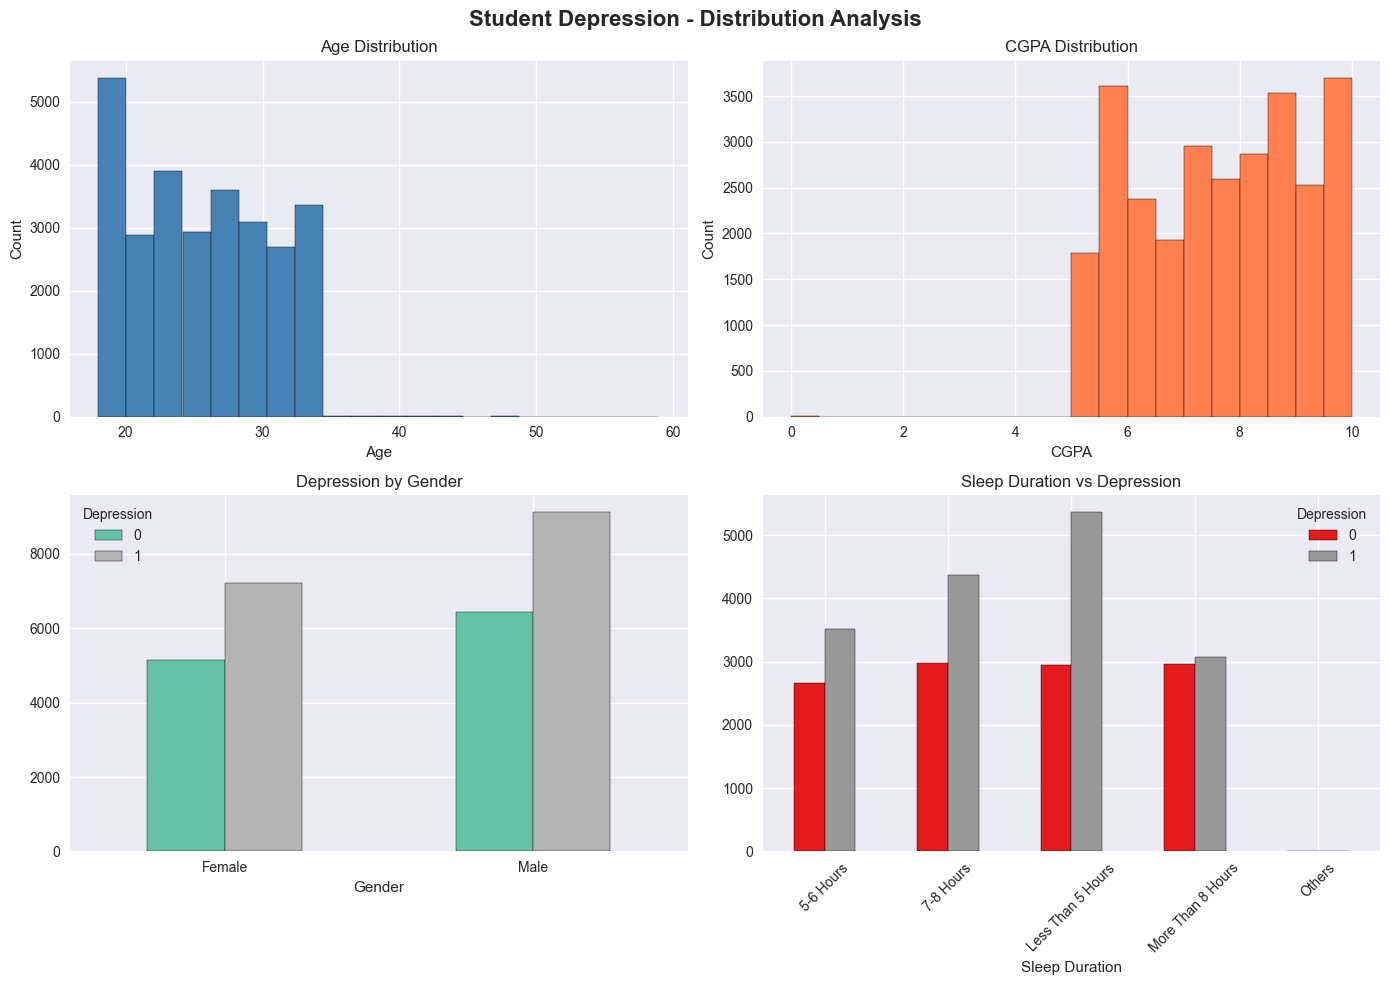

Chart saved!


In [16]:
# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Depression - Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Age Distribution
if 'Age' in df_clean.columns:
    axes[0,0].hist(df_clean['Age'].dropna(), bins=20, color='steelblue', edgecolor='black')
    axes[0,0].set_title('Age Distribution')
    axes[0,0].set_xlabel('Age')
    axes[0,0].set_ylabel('Count')

# 2. CGPA Distribution
if 'CGPA' in df_clean.columns:
    axes[0,1].hist(df_clean['CGPA'].dropna(), bins=20, color='coral', edgecolor='black')
    axes[0,1].set_title('CGPA Distribution')
    axes[0,1].set_xlabel('CGPA')
    axes[0,1].set_ylabel('Count')

# 3. Depression by Gender
if 'Gender' in df_clean.columns and 'Depression' in df_clean.columns:
    gender_dep = df_clean.groupby(['Gender', 'Depression']).size().unstack(fill_value=0)
    gender_dep.plot(kind='bar', ax=axes[1,0], colormap='Set2', edgecolor='black')
    axes[1,0].set_title('Depression by Gender')
    axes[1,0].set_xlabel('Gender')
    axes[1,0].tick_params(axis='x', rotation=0)

# 4. Sleep Duration vs Depression
if 'Sleep Duration' in df_clean.columns and 'Depression' in df_clean.columns:
    sleep_dep = df_clean.groupby(['Sleep Duration', 'Depression']).size().unstack(fill_value=0)
    sleep_dep.plot(kind='bar', ax=axes[1,1], colormap='Set1', edgecolor='black')
    axes[1,1].set_title('Sleep Duration vs Depression')
    axes[1,1].set_xlabel('Sleep Duration')
    axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

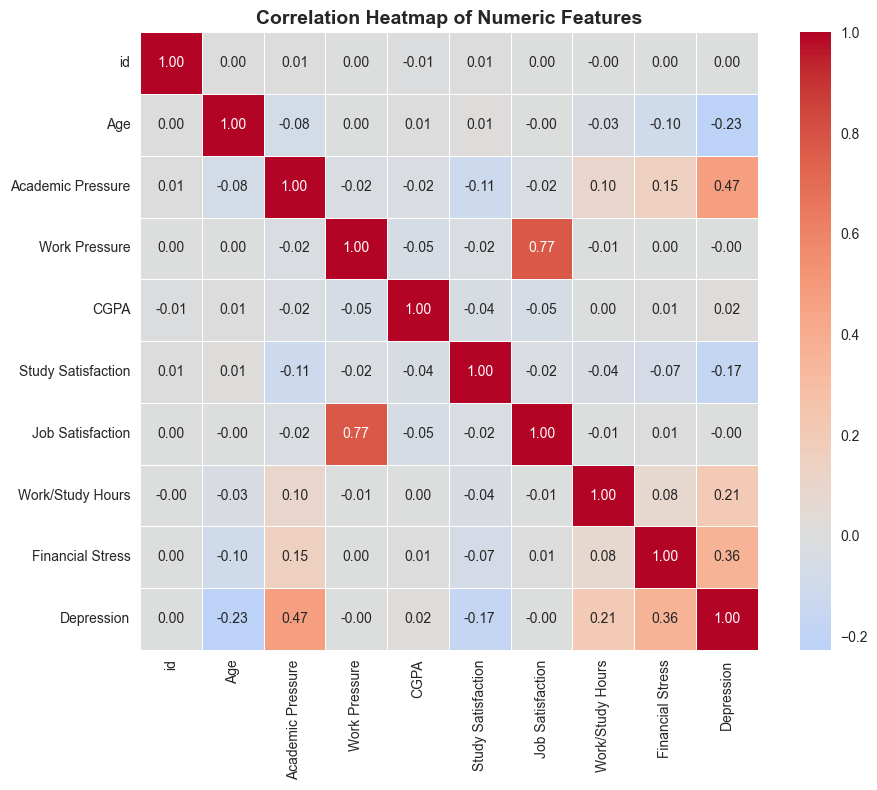

Heatmap saved!


In [17]:
plt.figure(figsize=(10, 8))
numeric_data = df_clean.select_dtypes(include=[np.number])
correlation = numeric_data.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

<Figure size 1000x500 with 0 Axes>

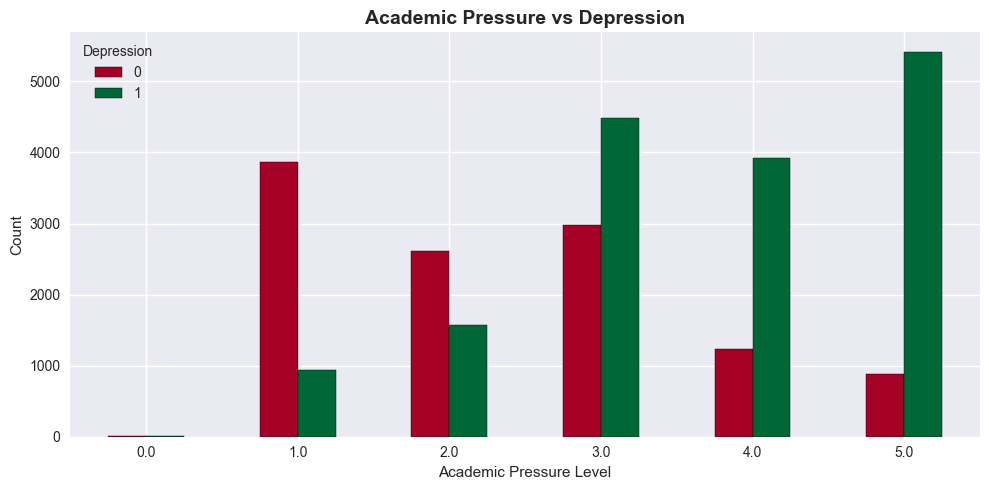

In [18]:
if 'Academic Pressure' in df_clean.columns and 'Depression' in df_clean.columns:
    plt.figure(figsize=(10, 5))
    ap_dep = df_clean.groupby(['Academic Pressure', 'Depression']).size().unstack(fill_value=0)
    ap_dep.plot(kind='bar', colormap='RdYlGn', edgecolor='black', figsize=(10,5))
    plt.title('Academic Pressure vs Depression', fontsize=14, fontweight='bold')
    plt.xlabel('Academic Pressure Level')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.legend(title='Depression')
    plt.tight_layout()
    plt.savefig('academic_pressure_depression.png', dpi=150, bbox_inches='tight')
    plt.show()

In [20]:
print("=" * 60)
print("KEY INSIGHTS FROM THE DATA")
print("=" * 60)

# Depression rate overall
if 'Depression' in df_clean.columns:
    dep_counts = df_clean['Depression'].value_counts()
    dep_rate = (dep_counts.get('Yes', dep_counts.get('1', 0)) / len(df_clean)) * 100
    print(f"\n1. Overall Depression Rate: {dep_rate:.1f}%")

# By gender
if 'Gender' in df_clean.columns and 'Depression' in df_clean.columns:
    print("\n2. Depression by Gender:")
    print(df_clean.groupby('Gender')['Depression'].value_counts(normalize=True).mul(100).round(1))

# CGPA vs Depression
if 'CGPA' in df_clean.columns and 'Depression' in df_clean.columns:
    print("\n3. Average CGPA by Depression Status:")
    print(df_clean.groupby('Depression')['CGPA'].mean().round(2))

# Age group vs depression
if 'Age_Group' in df_clean.columns and 'Depression' in df_clean.columns:
    print("\n4. Depression by Age Group:")
    print(df_clean.groupby('Age_Group')['Depression'].value_counts().unstack(fill_value=0))

KEY INSIGHTS FROM THE DATA

1. Overall Depression Rate: 0.0%

2. Depression by Gender:
Gender  Depression
Female  1             58.5
        0             41.5
Male    1             58.6
        0             41.4
Name: proportion, dtype: float64

3. Average CGPA by Depression Status:
Depression
0    7.62
1    7.68
Name: CGPA, dtype: float64

4. Depression by Age Group:
Depression     0     1
Age_Group             
Under 18     371  1216
18-21       1675  3848
22-25       2504  4343
26-30       3410  4435
30+         3605  2494


In [21]:
df_clean.to_csv('student_depression_cleaned.csv', index=False)
print("Cleaned dataset saved!")
print(f"Final shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Cleaned dataset saved!
Final shape: (27901, 20)
Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Age_Group', 'CGPA_Band']


In [ ]:
p